In [14]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
import os

current_path = os.getcwd()
parent_path = os.path.dirname(current_path)
sys.path.append(parent_path)


In [3]:
import sys
import os
from pathlib import Path

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)
import torch
from torch.utils.data import DataLoader
from utils.set_woof import ImagewoofColorizationDataset

DATA_DIR = Path("../imagewoof2-160") 

print(f"📂 Buscando datos en: {os.path.abspath(DATA_DIR)}")

# --- 3. Crear Datasets y Loaders (Tu código normal) ---
train_dataset = ImagewoofColorizationDataset(DATA_DIR, split="train")
val_dataset = ImagewoofColorizationDataset(DATA_DIR, split="val")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("¡Todo listo! ✅")

📂 Buscando datos en: /Users/damiandistefano/Documents/UDESA/3_año/2_semestre/Vision artificial/TPs/Tp_final_vision/imagewoof2-160
¡Todo listo! ✅


📊 Generando datos comparativos...
✨ ¡Mostrando la evolución del modelo!


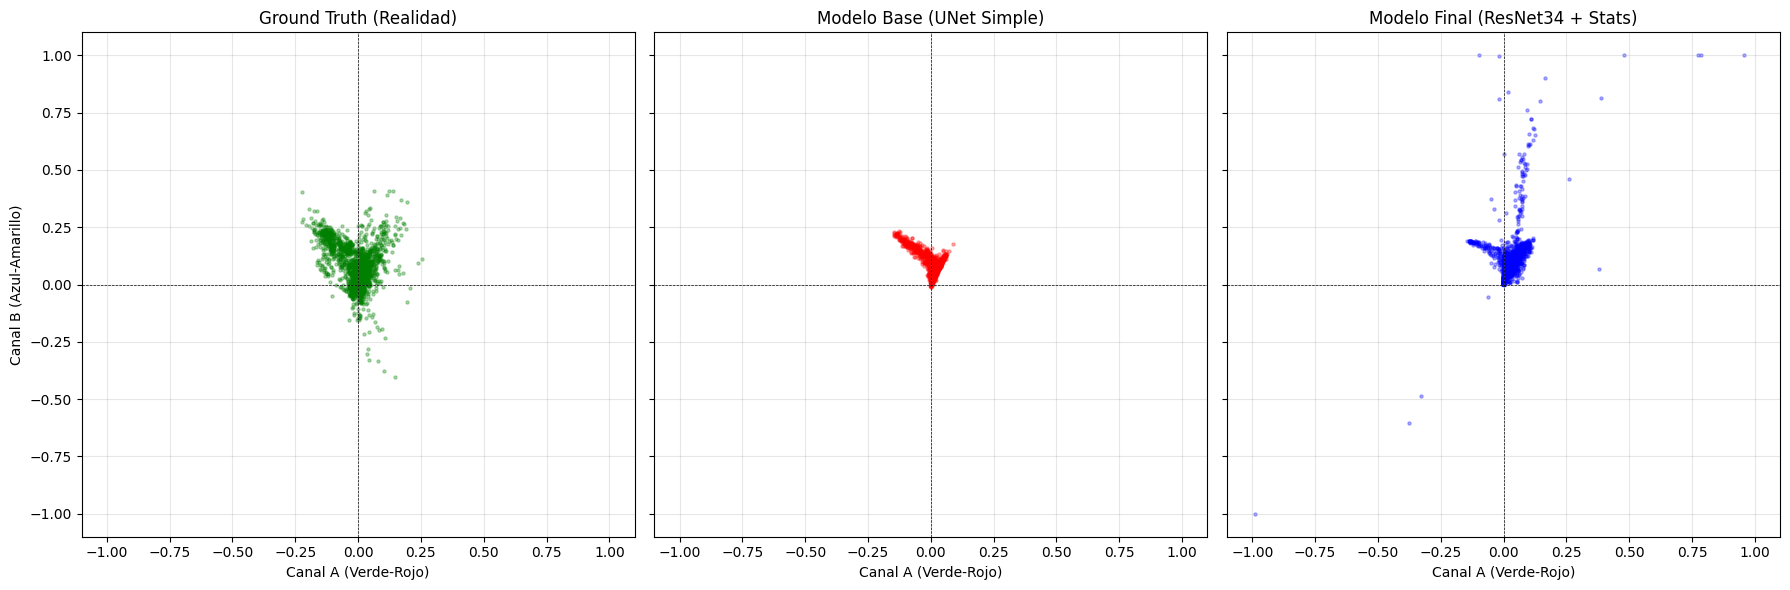

In [ ]:

from models.unet import UNetColor
from models.unet_resnet34 import get_model_unet_resnet34
from plots import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelo_base = UNetColor() 
modelo_resnet = get_model_unet_resnet34(pre_entrenado=True) 
modelo_hist = get_model_unet_resnet34(pre_entrenado=False)

path_base = "../pesos_entrenados/unetColor.pt"               
path_resnet = "../pesos_entrenados/unet_resnet34_combined.pt"  
path_hist = "../pesos_entrenados/unet_resnet34_histogram.pt"  

# Cargar pesos
modelo_base.load_state_dict(torch.load(path_base, map_location=device))
modelo_resnet.load_state_dict(torch.load(path_resnet, map_location=device))
modelo_hist.load_state_dict(torch.load(path_hist, map_location=device))
# Mover a GPU y poner en modo evaluación
modelo_base.to(device).eval()
modelo_resnet.to(device).eval()
modelo_hist.to(device).eval()

print("📊 Generando datos comparativos...")
real_data, viejo_data, nuevo_data, hist_data = get_data_for_plot(val_loader, modelo_base, modelo_resnet, modelo_hist, device)

print("✨ ¡Mostrando la evolución del modelo!")
plot_ab_distribution(real_data, viejo_data, nuevo_data, hist_data)

In [ ]:
mis_modelos = [modelo_base, modelo_resnet, modelo_hist]
mis_nombres = ["Modelo Base", "ResNet34 + SSIM", "Modelo Histograma (UNet-ResNet34)"]
plot_saturation_hist(val_loader, mis_modelos, mis_nombres, device)

TypeError: plot_saturation_hist() takes 3 positional arguments but 4 were given